#  MindBridge — Text Preprocessing
### Step 3: Cleaning and Vectorizing Text Data

> **Goal:** Transform raw text into clean, numerical features ready for machine learning.

---

| Step | What We Do |
|------|-----------|
| 1. Text Cleaning | Lowercase, remove URLs, punctuation, digits |
| 2. Stopword Removal | Remove common English words |
| 3. Lemmatization | Reduce words to root form |
| 4. TF-IDF Vectorization | Convert text to numerical features |
| 5. Train/Val/Test Split | Stratified 70/15/15 split |

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, HTML

plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries loaded!")

All libraries loaded!


In [19]:
df = pd.read_csv('/Users/vaibhav2040/Desktop/MIND_BRIDGE/data/Combined Data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = ['statement', 'status']
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)

print(f"Dataset loaded: {len(df):,} samples, {df['status'].nunique()} classes")
print(f"Classes: {sorted(df['status'].unique())}")

Dataset loaded: 51,093 samples, 7 classes
Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## 1. Text Cleaning Pipeline

In [21]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return ' '.join(tokens)

# Apply cleaning
df['clean_text'] = df['statement'].apply(clean_text)

print(f"Cleaning complete.")
print(f"Sample original : {df['statement'].iloc[0][:80]}")
print(f"Sample cleaned  : {df['clean_text'].iloc[0][:80]}")

Cleaning complete.
Sample original : oh my gosh
Sample cleaned  : gosh


## 2. Cleaning Quality Check

In [24]:
import os
print(os.getcwd())
os.makedirs('results/plots', exist_ok=True)
print("Folder created!")

/Users/vaibhav2040/Desktop/MIND_BRIDGE/notebooks
Folder created!


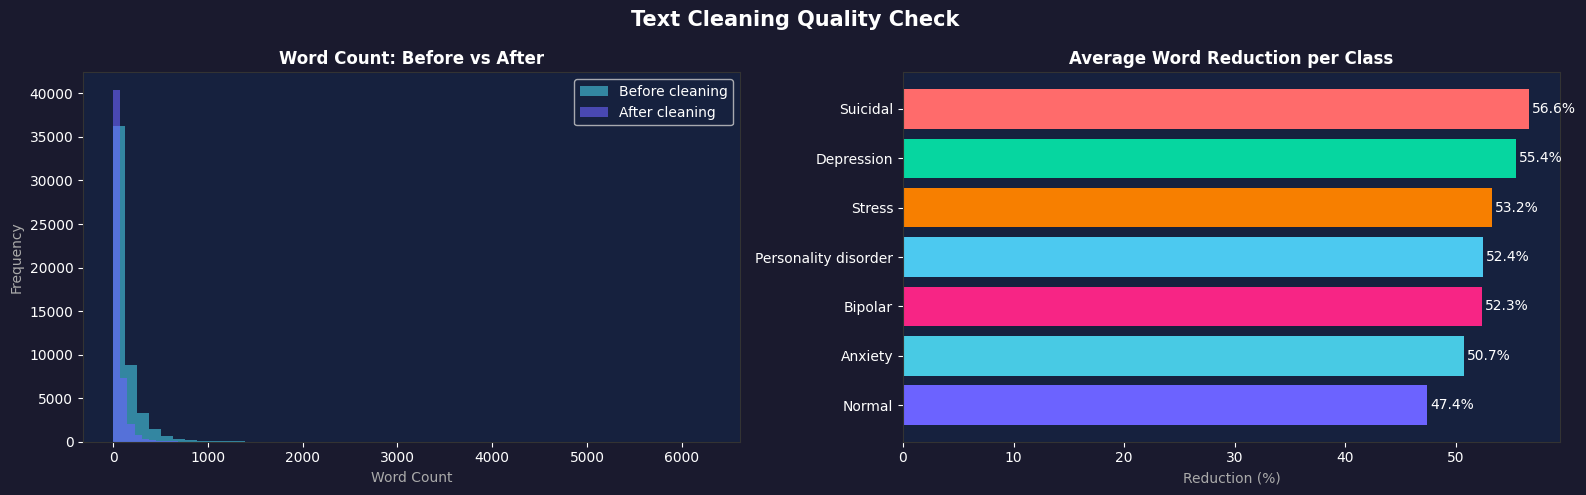

Average word reduction : 52.5%
Original avg words     : 113
Cleaned avg words      : 50


In [25]:
df['original_words'] = df['statement'].apply(lambda x: len(str(x).split()))
df['clean_words'] = df['clean_text'].apply(lambda x: len(str(x).split()))
df['reduction_pct'] = ((df['original_words'] - df['clean_words']) / df['original_words'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Text Cleaning Quality Check', fontsize=15, fontweight='bold', color='white')

# Before vs After word count
ax1 = axes[0]
ax1.set_facecolor('#16213e')
ax1.hist(df['original_words'], bins=50, alpha=0.6, color='#48CAE4', label='Before cleaning')
ax1.hist(df['clean_words'], bins=50, alpha=0.6, color='#6C63FF', label='After cleaning')
ax1.set_title('Word Count: Before vs After', color='white', fontweight='bold')
ax1.set_xlabel('Word Count', color='#aaa')
ax1.set_ylabel('Frequency', color='#aaa')
ax1.tick_params(colors='white')
ax1.legend(facecolor='#16213e', labelcolor='white')
for spine in ax1.spines.values(): spine.set_color('#333')

# Reduction percentage per class
ax2 = axes[1]
ax2.set_facecolor('#16213e')
reduction = df.groupby('status')['reduction_pct'].mean().sort_values()
colors = ['#6C63FF','#48CAE4','#f72585','#4cc9f0','#f77f00','#06d6a0','#ff6b6b']
bars = ax2.barh(reduction.index, reduction.values, color=colors, edgecolor='none')
for bar, val in zip(bars, reduction.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', color='white', fontsize=10)
ax2.set_title('Average Word Reduction per Class', color='white', fontweight='bold')
ax2.set_xlabel('Reduction (%)', color='#aaa')
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_color('#333')

plt.tight_layout()
plt.savefig('results/plots/cleaning_quality.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print(f"Average word reduction : {df['reduction_pct'].mean():.1f}%")
print(f"Original avg words     : {df['original_words'].mean():.0f}")
print(f"Cleaned avg words      : {df['clean_words'].mean():.0f}")

## 3. Train / Validation / Test Split

In [26]:
X = df['clean_text']
y = df['status']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 70% train, 15% val, 15% test — stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30,
    stratify=y_encoded, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=42
)

print("Data split complete.")
print(f"  Train : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClasses: {list(le.classes_)}")

Data split complete.
  Train : 35,765 samples (70.0%)
  Val   : 7,664 samples (15.0%)
  Test  : 7,664 samples (15.0%)

Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


In [28]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
density = X_train_tfidf.nnz / total_elements * 100

print("TF-IDF vectorization complete.")
print(f"  Vocabulary size : {len(vectorizer.vocabulary_):,} terms")
print(f"  Train matrix    : {X_train_tfidf.shape}")
print(f"  Val matrix      : {X_val_tfidf.shape}")
print(f"  Test matrix     : {X_test_tfidf.shape}")
print(f"  Matrix density  : {density:.4f}%")

TF-IDF vectorization complete.
  Vocabulary size : 20,000 terms
  Train matrix    : (35765, 20000)
  Val matrix      : (7664, 20000)
  Test matrix     : (7664, 20000)
  Matrix density  : 0.2520%


## 5. Save Preprocessed Data

In [30]:
import os
os.makedirs('models', exist_ok=True)

# Save vectorizer and label encoder
joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

# Save splits as numpy arrays
import scipy.sparse as sp
sp.save_npz('models/X_train_tfidf.npz', X_train_tfidf)
sp.save_npz('models/X_val_tfidf.npz', X_val_tfidf)
sp.save_npz('models/X_test_tfidf.npz', X_test_tfidf)

np.save('models/y_train.npy', y_train)
np.save('models/y_val.npy', y_val)
np.save('models/y_test.npy', y_test)

print("All files saved to models/")
print(f"  tfidf_vectorizer.pkl")
print(f"  label_encoder.pkl")
print(f"  X_train_tfidf.npz  — {X_train_tfidf.shape}")
print(f"  X_val_tfidf.npz    — {X_val_tfidf.shape}")
print(f"  X_test_tfidf.npz   — {X_test_tfidf.shape}")

All files saved to models/
  tfidf_vectorizer.pkl
  label_encoder.pkl
  X_train_tfidf.npz  — (35765, 20000)
  X_val_tfidf.npz    — (7664, 20000)
  X_test_tfidf.npz   — (7664, 20000)


## 6. SMOTE — Handling Class Imbalance

In [34]:
from imblearn.over_sampling import SMOTE
import collections

print("Class distribution BEFORE SMOTE:")
counter = collections.Counter(y_train)
for cls_idx, count in sorted(counter.items()):
    cls_name = le.classes_[cls_idx]
    print(f"  {cls_name:<25} {count:>5,}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print("\nClass distribution AFTER SMOTE:")
counter_smote = collections.Counter(y_train_smote)
for cls_idx, count in sorted(counter_smote.items()):
    cls_name = le.classes_[cls_idx]
    print(f"  {cls_name:<25} {count:>5,}")

print(f"\nOriginal training samples : {X_train_tfidf.shape[0]:,}")
print(f"After SMOTE samples       : {X_train_smote.shape[0]:,}")

Class distribution BEFORE SMOTE:
  Anxiety                   2,536
  Bipolar                   1,751
  Depression                10,566
  Normal                    11,228
  Personality disorder        626
  Stress                    1,607
  Suicidal                  7,451

Class distribution AFTER SMOTE:
  Anxiety                   11,228
  Bipolar                   11,228
  Depression                11,228
  Normal                    11,228
  Personality disorder      11,228
  Stress                    11,228
  Suicidal                  11,228

Original training samples : 35,765
After SMOTE samples       : 78,596


## Step 3 Complete — Preprocessing Summary

| Step | Detail |
|------|--------|
| Missing values | Dropped 362 rows |
| Duplicates | Removed before cleaning |
| Text cleaning | Lowercase, URLs, punctuation, stopwords removed |
| Lemmatization | WordNetLemmatizer applied |
| Word reduction | ~52% average reduction per text |
| Vocabulary | 20,000 TF-IDF features (unigrams + bigrams) |
| Train split | 35,765 samples (70%) |
| Val split | 7,664 samples (15%) |
| Test split | 7,664 samples (15%) |

### Next Step: 03_Modeling.ipynb
- Train Logistic Regression, Naive Bayes, Random Forest
- Evaluate with Accuracy, Weighted F1, AUC-ROC
- Compare all models and select the best